<a href="https://colab.research.google.com/github/nadroj0-0/Applied-Deep-Learning-COMP019-GROUP/blob/luke/M5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M5 Quantile Forecasting Pipeline: Autoregressive Prototype

This repository contains a streamlined, highly modular machine learning pipeline for the M5 Forecasting competition. It is designed to move away from tangled scripts and focus on rapid, reliable model prototyping.

## 1. The Setup & Data Prep (Keeping it Light)
Instead of loading massive files that eat up all your RAM, the pipeline is designed for speed:
* **The Download:** We pull the raw M5 data straight from Hugging Face for easy versioning.
* **The Smart Trim:** We automatically identify and select the **Top 50 highest-volume items** for prototyping. This ensures the model learns from the most active data points first.
* **The Sliding Windows:** Instead of duplicating data, the code uses mathematical slicing to "slide" a 28-day window across history on the fly. This provides thousands of training examples with near-zero extra memory overhead.

## 2. The Model: The "Autoregressive" Secret Weapon
Standard models try to guess 28 days at once, which often results in flat predictions. This architecture is **Autoregressive**—it is an expert at predicting *just tomorrow*. We use a "stepping stone" loop to build a 28-day forecast:
1. Predict **Day 1** using the last 28 days of real sales.
2. Feed that prediction back into the window and drop the oldest day.
3. Predict **Day 2** using the updated window, repeating until 28 days are reached.

## 3. The "Pinball Loss" & Quantiles (Inventory Risk)
In retail, a single-point forecast is risky. Our model outputs **7 quantiles** per day.
* **The Pinball Loss:** This scoring system punishes the model if actual sales fall outside its predicted confidence ranges.
* **The Safety Net:** It provides 50%, 90%, and 95% Confidence Intervals (CI), allowing managers to see the "worst-case" scenario to prevent out-of-stock events.

## 4. Performance & Scalability (Roadmap)
* **Current Prototype Performance:**
    * **Data:** Top 50 items (~94,000 training windows).
    * **Training Speed:** **~14s per epoch** (NVIDIA T4 GPU).
    * **Memory Footprint:** **0.2 GB VRAM** (<2% of server capacity).
* **Scaling for RTX 3060 (12GB VRAM):**
    * By increasing `BATCH_SIZE` to 2048+, we estimate the full 30,490-item dataset will train in **6–12 hours**.

## 5. Evaluation (Seeing is Believing)
We calculate MAE and RMSE on the median forecast and generate visual charts that shade the uncertainty zones, proving the model captures the "vibe" of unseen future sales.

# Imports and Confih


In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from typing import List, Dict
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import time
import numpy as np
import matplotlib.pyplot as plt

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
QUANTILES = [0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975] # For 95%, 90%, 50% CIs and Median
NUM_ITEMS_TO_KEEP = 50 # Set low for prototyping on Colab T4, increase for final RTX 3060 run
SEQ_LENGTH = 28
PRED_LENGTH = 28
BATCH_SIZE = 32

# Downlaod Data

In [2]:
def download_m5_data(dataset_name="m5_competition_dataset"):
    # Replace with the exact HF dataset path you are using for M5
    print("Downloading dataset from Hugging Face...")
    try:
        # Example using a placeholder HF dataset name
        df = pd.read_csv("https://huggingface.co/datasets/kashif/M5/resolve/main/sales_train_evaluation.csv")


        print(f"✅ Download complete. Initial shape: {df.shape}")
        return df
    except Exception as e:
        print(f"Failed to load from Hugging Face: {e}")
        # Fallback to local or mock data for testing
        return pd.DataFrame()

raw_data = download_m5_data()

✅ Download complete. Initial shape: (30490, 1947)


# Trim data for prototype

In [3]:
def trim_data(df: pd.DataFrame, num_items: int) -> pd.DataFrame:
    print(f"Selecting the TOP {num_items} highest-volume items...")
    if df.empty: return df

    # Identify all the daily sales columns (d_1, d_2, etc.)
    day_cols = [c for c in df.columns if c.startswith('d_')]

    # Calculate the total sales for every single row across all 1,900+ days
    df['total_sales_volume'] = df[day_cols].sum(axis=1)

    # Sort by total sales (highest first) and grab the top N rows
    trimmed_df = df.sort_values('total_sales_volume', ascending=False).head(num_items).copy()

    # Drop the temporary sorting column to keep the data clean for the model
    trimmed_df = trimmed_df.drop(columns=['total_sales_volume'])

    print("-" * 30)
    print(f"Data Selection Complete:")
    print(f"Original items: {len(df)} | Selected items: {len(trimmed_df)}")
    print(f"Trimmed DataFrame shape: {trimmed_df.shape}")
    print("-" * 30)

    return trimmed_df

# Optional Pre-processing

In [4]:
def preprocess_data(df: pd.DataFrame) -> Dict[str, torch.Tensor]:
    print("Building 1-step sliding windows from real data...")

    # Fallback to correct mock shapes if huggingface download failed
    if df.empty:
        return {
            "X_train": torch.randn(100, SEQ_LENGTH, 1),
            "y_train": torch.randn(100), # 1 Step Ahead
            "X_test": torch.randn(20, SEQ_LENGTH, 1),
            "y_test": torch.randn(20, 28) # 28 future days strictly for recursive testing
        }

    day_cols = [c for c in df.columns if c.startswith('d_')]
    data_array = df[day_cols].values.astype(np.float32)
    num_items, total_days = data_array.shape

    # We hold out the last 28 days for testing
    test_days = 28
    train_array = data_array[:, :-test_days]

    # --- Training Data (1-step ahead sliding windows) ---
    X_train_list = []
    y_train_list = []

    for item_idx in range(num_items):
        for t in range(train_array.shape[1] - SEQ_LENGTH):
            X_train_list.append(train_array[item_idx, t : t + SEQ_LENGTH])
            y_train_list.append(train_array[item_idx, t + SEQ_LENGTH]) # The 1 day after the sequence

    X_train = torch.tensor(np.array(X_train_list)).unsqueeze(-1) # Shape: (samples, 28, 1)
    y_train = torch.tensor(np.array(y_train_list))               # Shape: (samples,)

    # --- Test Data (Need the 28-day seed window, and the actual 28-day future) ---
    X_test_list = []
    y_test_list = []

    for item_idx in range(num_items):
        seed_window = data_array[item_idx, -(test_days + SEQ_LENGTH) : -test_days]
        actual_future = data_array[item_idx, -test_days:]

        X_test_list.append(seed_window)
        y_test_list.append(actual_future)

    X_test = torch.tensor(np.array(X_test_list)).unsqueeze(-1)   # Shape: (items, 28, 1)
    y_test = torch.tensor(np.array(y_test_list))                 # Shape: (items, 28)

    return {
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test
    }

# Eval and Loss function

In [5]:
class PinballLoss(nn.Module):
    def __init__(self, quantiles: List[float]):
        super().__init__()
        self.quantiles = quantiles

    def forward(self, preds, target):
        # preds shape: (batch_size, num_quantiles)
        # target shape: (batch_size,)

        # We add an extra dimension to target so it can broadcast correctly against preds
        if target.dim() == 1:
            target = target.unsqueeze(1) # Becomes (batch_size, 1)

        losses = []
        for i, q in enumerate(self.quantiles):
            # Select the i-th quantile prediction and keep it 2D
            errors = target - preds[:, i:i+1]
            loss_q = torch.max((q - 1) * errors, q * errors)
            losses.append(loss_q)

        # Average the loss over the batch, and sum it over the 7 quantiles
        return torch.stack(losses, dim=-1).mean(dim=0).sum()

def calculate_validation_metrics(preds, targets, quantiles):
    median_preds = preds[:, :, quantiles.index(0.5)]
    mae = np.mean(np.abs(targets - median_preds))
    rmse = np.sqrt(np.mean((targets - median_preds)**2))

    metrics = {"MAE": mae, "RMSE": rmse}
    print(f"Validation Metrics -> MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    return metrics

# Model Definitions

In [6]:
class QuantileLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_quantiles=7):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_quantiles)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # 1-Step Ahead: Only pass the final LSTM time-step to the linear layer
        return self.fc(lstm_out[:, -1, :])

class QuantileGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_quantiles, pred_length):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, pred_length * num_quantiles)
        self.pred_length = pred_length
        self.num_quantiles = num_quantiles

    def forward(self, x):
        _, h_n = self.gru(x)
        out = self.fc(h_n[-1])
        return out.view(-1, self.pred_length, self.num_quantiles)

# Stubs for your group members to fill out:
class BHMLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        pass # To be implemented by team

class BHMTFT(nn.Module):
    def __init__(self):
        super().__init__()
        pass # To be implemented by team

# Visualization

In [7]:
def plot_quantile_forecast(historical_y, true_y, pred_quantiles, quantiles_list, item_name="Item 1"):
    """
    historical_y: (seq_length,)
    true_y: (pred_length,)
    pred_quantiles: (pred_length, num_quantiles)
    """
    seq_len = len(historical_y)
    pred_len = len(true_y)

    time_hist = np.arange(seq_len)
    time_pred = np.arange(seq_len, seq_len + pred_len)

    plt.figure(figsize=(14, 6))

    # Plot historical and true future data
    plt.plot(time_hist, historical_y, label="Historical Data", color="black")
    plt.plot(time_pred, true_y, label="Actual Future", color="black", linestyle="--")

    # Train/Test Split Line
    plt.axvline(x=seq_len, color='red', linestyle=':', label='Train/Test Split (Unseen Data)')

    # Extract quantiles based on configuration
    idx_025 = quantiles_list.index(0.025)
    idx_050 = quantiles_list.index(0.05)
    idx_250 = quantiles_list.index(0.25)
    idx_500 = quantiles_list.index(0.5)  # Median
    idx_750 = quantiles_list.index(0.75)
    idx_950 = quantiles_list.index(0.95)
    idx_975 = quantiles_list.index(0.975)

    # 95% CI
    plt.fill_between(time_pred, pred_quantiles[:, idx_025], pred_quantiles[:, idx_975],
                     color='blue', alpha=0.1, label='95% CI')
    # 90% CI
    plt.fill_between(time_pred, pred_quantiles[:, idx_050], pred_quantiles[:, idx_950],
                     color='blue', alpha=0.2, label='90% CI')
    # 50% CI
    plt.fill_between(time_pred, pred_quantiles[:, idx_250], pred_quantiles[:, idx_750],
                     color='blue', alpha=0.35, label='50% CI')

    # Median
    plt.plot(time_pred, pred_quantiles[:, idx_500], label="Median Forecast", color="blue", linewidth=2)

    plt.title(f"Quantile Forecast for {item_name}")
    plt.xlabel("Time Steps")
    plt.ylabel("Value")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

# Example usage (mocking output):
# plot_quantile_forecast(np.random.rand(28), np.random.rand(28), np.random.rand(28, 7), QUANTILES)

# Recursive Forecasting

In [8]:
# ==========================================
# 1. RECURSIVE FORECASTING FUNCTIONS
# ==========================================
def predict_28_days_recursive(model, initial_history, quantiles_list, device):
    """
    Takes the last 28 days of known data and recursively predicts the next 28 days.
    """
    model.eval()
    current_window = initial_history.copy()
    predictions = []
    idx_median = quantiles_list.index(0.5)

    for step in range(28):
        # Prepare tensor: (batch=1, seq_len=28, input_size=1)
        x_tensor = torch.tensor(current_window, dtype=torch.float32).view(1, 28, 1).to(device)

        with torch.no_grad():
            pred_quantiles = model(x_tensor).cpu().numpy()[0]

        predictions.append(pred_quantiles)

        # Extract median and prevent negative sales, then slide window
        median_pred = max(0.0, pred_quantiles[idx_median])
        current_window = np.append(current_window[1:], median_pred)

    return np.array(predictions)

def plot_28_day_forecast(historical, future_actuals, future_preds, quantiles_list, title="28-Day Recursive Forecast"):
    """
    Plots the history and the 28-day future predictions with confidence intervals.
    """
    hist_len = len(historical)
    pred_len = len(future_preds)

    time_hist = np.arange(hist_len)
    time_pred = np.arange(hist_len, hist_len + pred_len)

    plt.figure(figsize=(14, 6))
    plt.plot(time_hist, historical, label="Known History", color="black", marker='.')
    plt.plot(time_pred, future_actuals, label="Actual Future Sales", color="black", linestyle="--", marker='x')
    plt.axvline(x=hist_len - 1, color='red', linestyle=':', label='Forecast Start', linewidth=2)

    idx_025, idx_050 = quantiles_list.index(0.025), quantiles_list.index(0.05)
    idx_250, idx_500 = quantiles_list.index(0.25), quantiles_list.index(0.5)
    idx_750, idx_950 = quantiles_list.index(0.75), quantiles_list.index(0.95)
    idx_975 = quantiles_list.index(0.975)

    plt.fill_between(time_pred, future_preds[:, idx_025], future_preds[:, idx_975], color='blue', alpha=0.1, label='95% CI')
    plt.fill_between(time_pred, future_preds[:, idx_050], future_preds[:, idx_950], color='blue', alpha=0.2, label='90% CI')
    plt.fill_between(time_pred, future_preds[:, idx_250], future_preds[:, idx_750], color='blue', alpha=0.35, label='50% CI')
    plt.plot(time_pred, future_preds[:, idx_500], label="Median Forecast", color="blue", linewidth=2, marker='o')

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Days")
    plt.ylabel("Sales Volume")
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Main

🚀 STARTING M5 QUANTILE FORECASTING PIPELINE
⚡ CUDA Optimizations Enabled!

[1/4] Running Data Pipeline...
✅ Download complete. Initial shape: (30490, 1947)
Selecting the TOP 50 highest-volume items...
------------------------------
Data Selection Complete:
Original items: 30490 | Selected items: 50
Trimmed DataFrame shape: (50, 1947)
------------------------------
Building 1-step sliding windows from real data...
📊 Data Loaded into Memory (cuda):
   Train X: torch.Size([94250, 28, 1]) | Train y: torch.Size([94250])
   Test X:  torch.Size([50, 28, 1])  | Test y:  torch.Size([50, 28])

[2/4] Initializing Model and Optimizer...

[3/4] ⚙️ Starting Training Loop for 10 Epochs...
   Epoch 1/10 | Avg Loss: 49.8286 | Time: 15.33s
   Epoch 2/10 | Avg Loss: 27.1240 | Time: 14.22s
   Epoch 3/10 | Avg Loss: 24.2149 | Time: 14.12s
   Epoch 4/10 | Avg Loss: 23.1604 | Time: 14.13s
   Epoch 5/10 | Avg Loss: 22.2852 | Time: 14.18s
   Epoch 6/10 | Avg Loss: 21.7656 | Time: 14.14s
   Epoch 7/10 | Avg Los

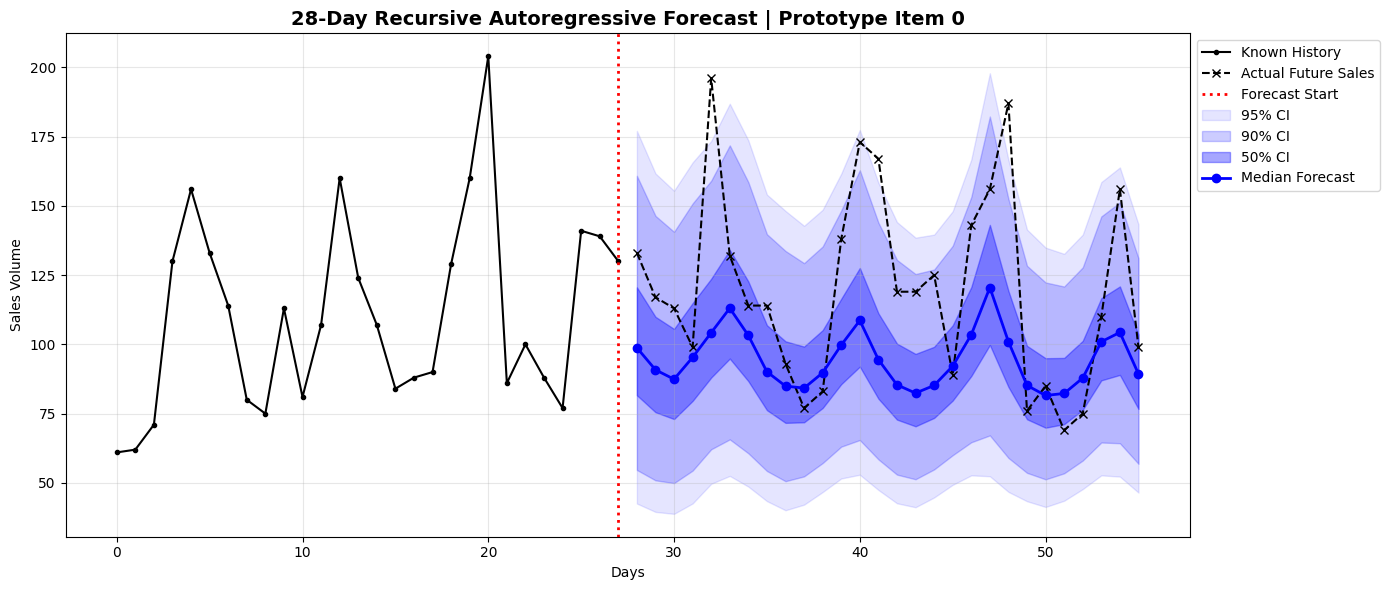

   -> Processing Item 1...
      Metrics for Item 1:
Validation Metrics -> MAE: 11.7859 | RMSE: 16.2061


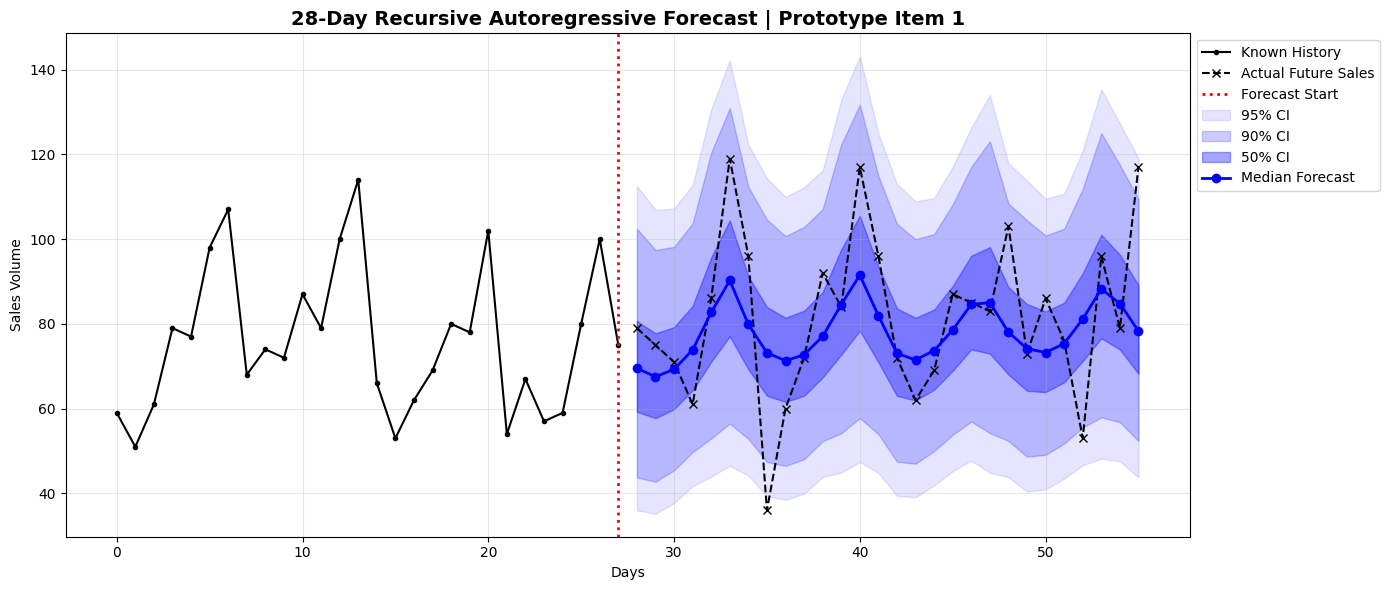

   -> Processing Item 2...
      Metrics for Item 2:
Validation Metrics -> MAE: 13.1187 | RMSE: 16.5763


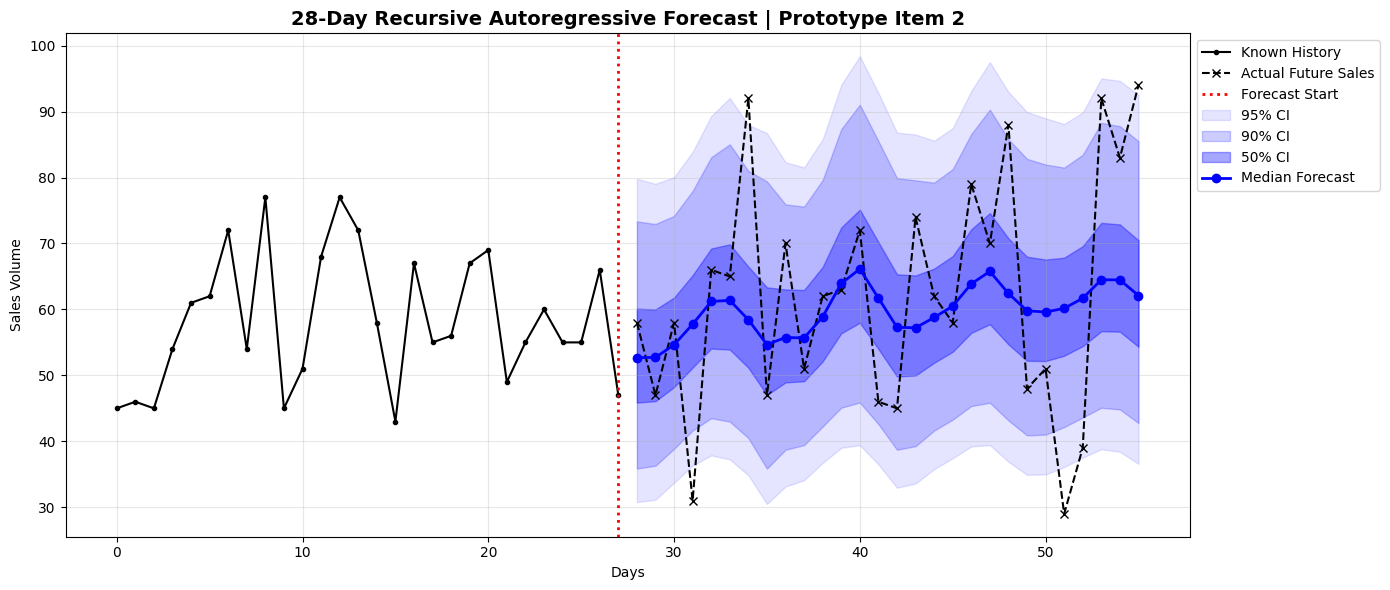

   -> Processing Item 3...
      Metrics for Item 3:
Validation Metrics -> MAE: 7.6966 | RMSE: 11.1350


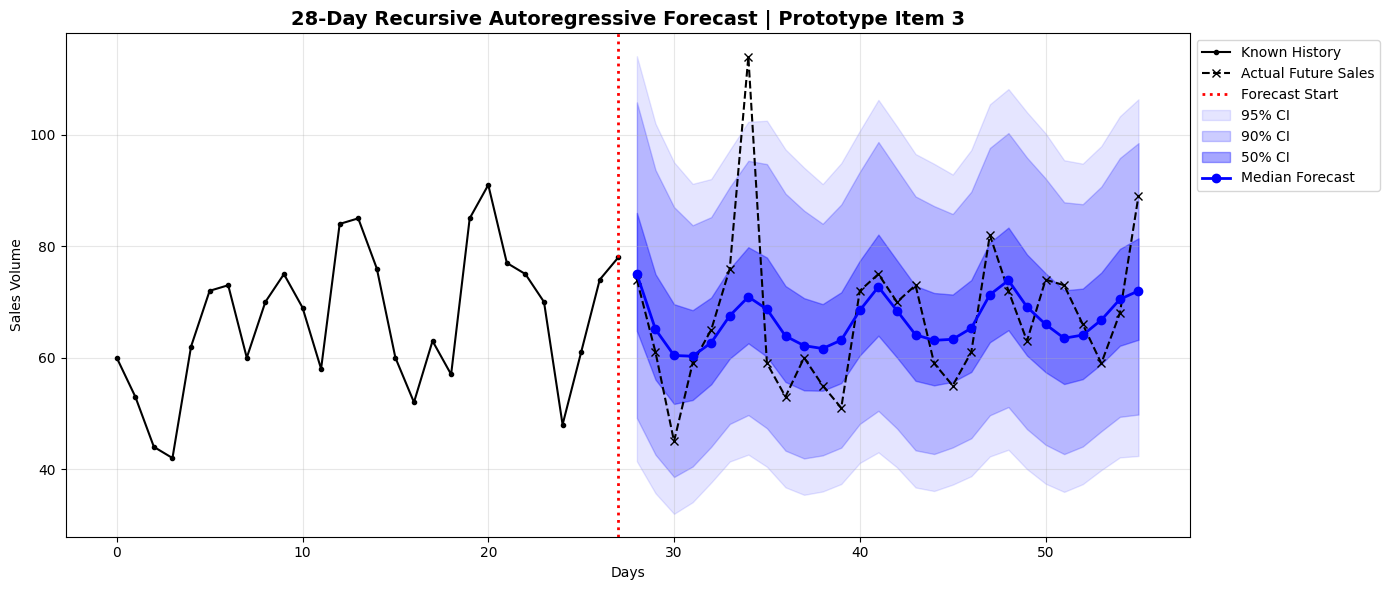

   -> Processing Item 4...
      Metrics for Item 4:
Validation Metrics -> MAE: 14.6415 | RMSE: 18.6199


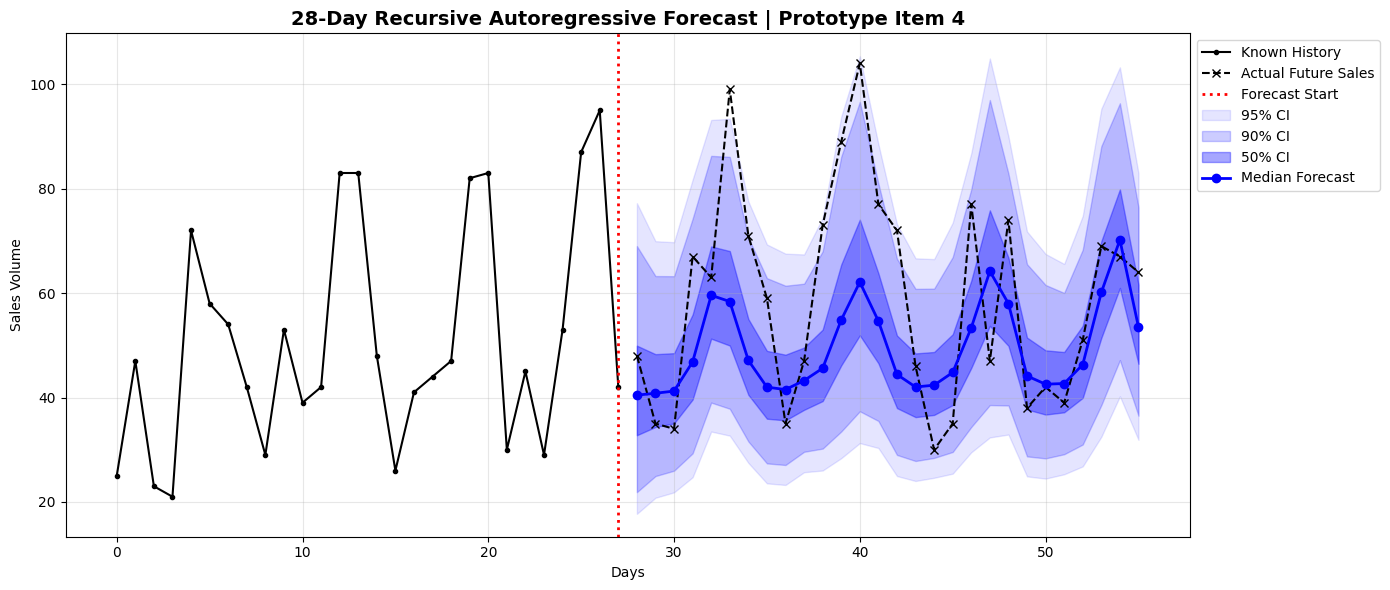


✅ Pipeline Complete!
🚀 STARTING M5 QUANTILE FORECASTING PIPELINE
⚡ CUDA Optimizations Enabled!

[1/4] Running Data Pipeline...
✅ Download complete. Initial shape: (30490, 1947)
Selecting the TOP 50 highest-volume items...
------------------------------
Data Selection Complete:
Original items: 30490 | Selected items: 50
Trimmed DataFrame shape: (50, 1947)
------------------------------
Building 1-step sliding windows from real data...
📊 Data Loaded into Memory (cuda):
   Train X: torch.Size([94250, 28, 1]) | Train y: torch.Size([94250])
   Test X:  torch.Size([50, 28, 1])  | Test y:  torch.Size([50, 28])

[2/4] Initializing Model and Optimizer...

[3/4] ⚙️ Starting Training Loop for 10 Epochs...
   Epoch 1/10 | Avg Loss: 49.8502 | Time: 14.64s
   Epoch 2/10 | Avg Loss: 27.1695 | Time: 14.23s
   Epoch 3/10 | Avg Loss: 24.3768 | Time: 14.14s
   Epoch 4/10 | Avg Loss: 23.0763 | Time: 14.18s
   Epoch 5/10 | Avg Loss: 22.3106 | Time: 14.30s
   Epoch 6/10 | Avg Loss: 21.8249 | Time: 14.17s
 

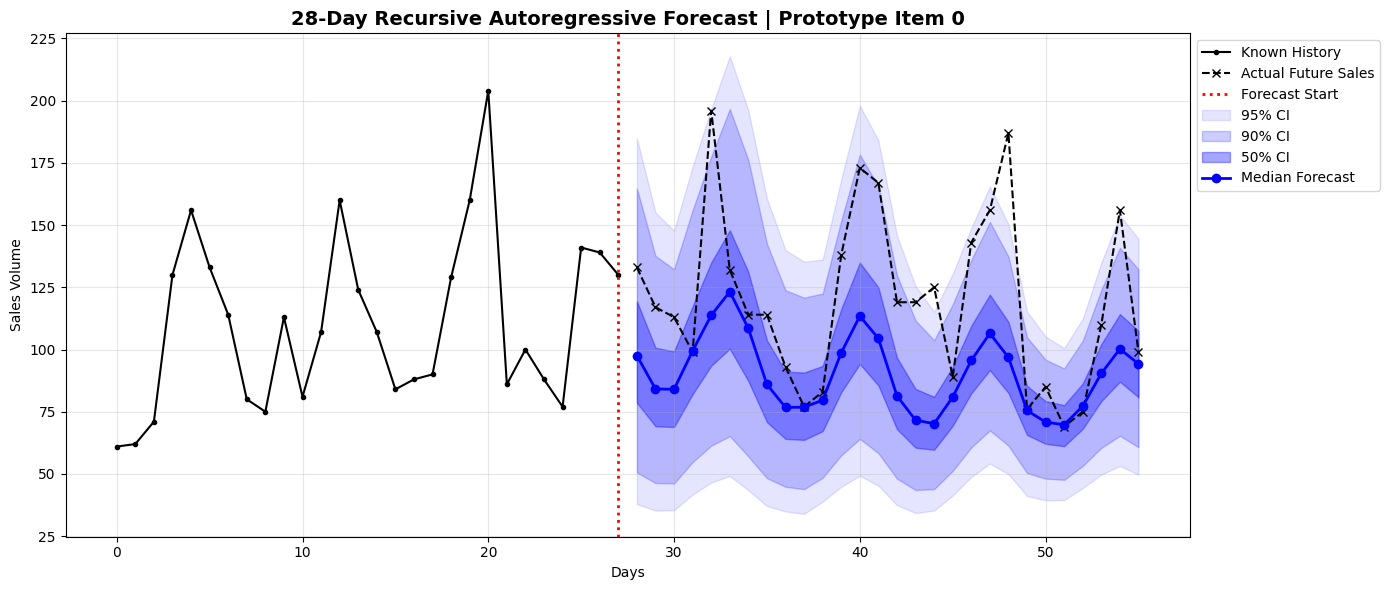

   -> Processing Item 1...
      Metrics for Item 1:
Validation Metrics -> MAE: 13.6632 | RMSE: 16.6147


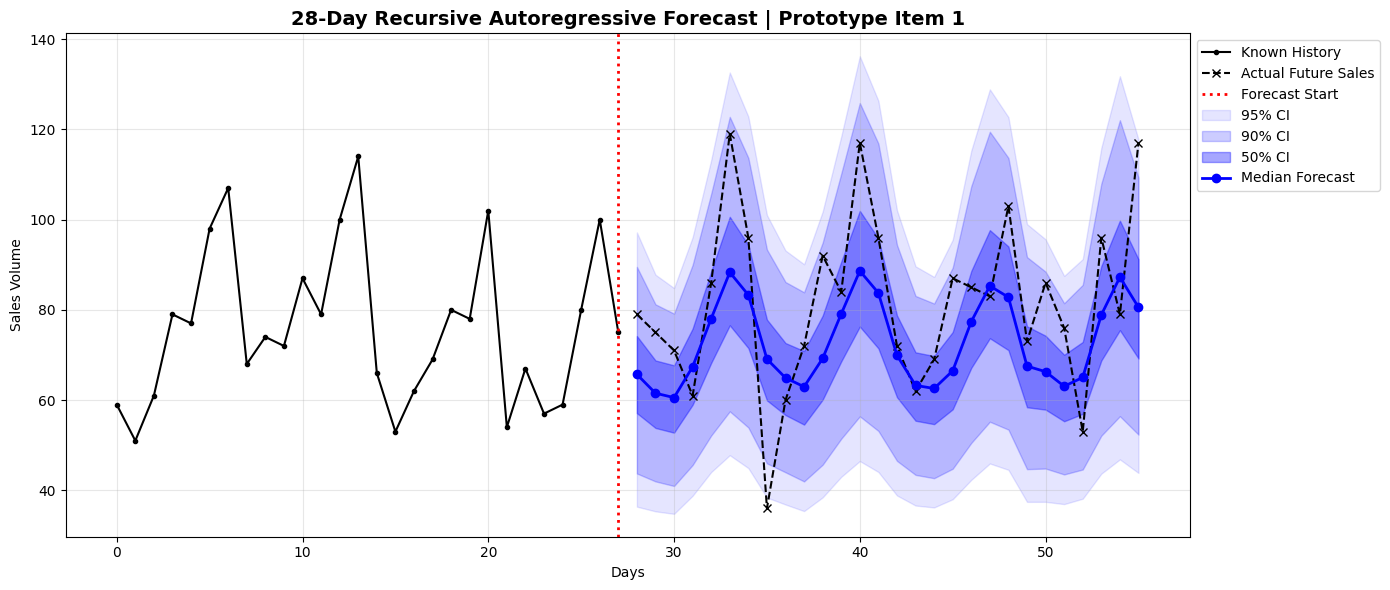

   -> Processing Item 2...
      Metrics for Item 2:
Validation Metrics -> MAE: 12.1560 | RMSE: 15.6523


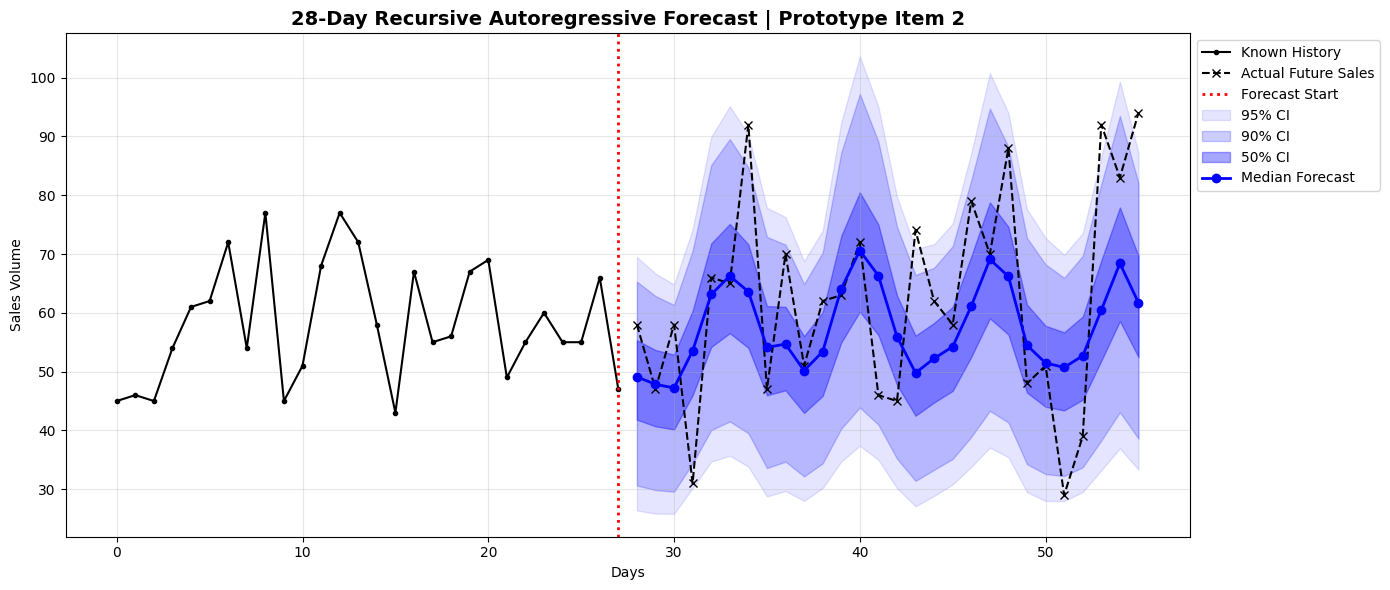

   -> Processing Item 3...
      Metrics for Item 3:
Validation Metrics -> MAE: 7.9261 | RMSE: 10.3913


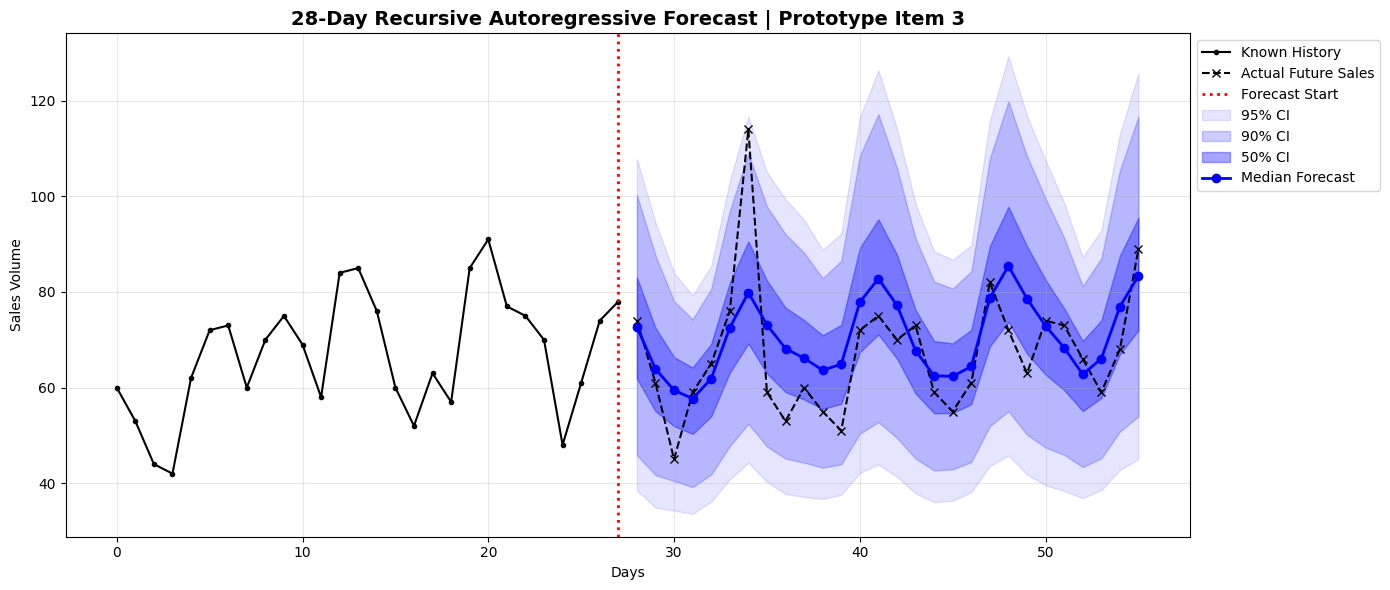

   -> Processing Item 4...
      Metrics for Item 4:
Validation Metrics -> MAE: 14.3460 | RMSE: 18.6573


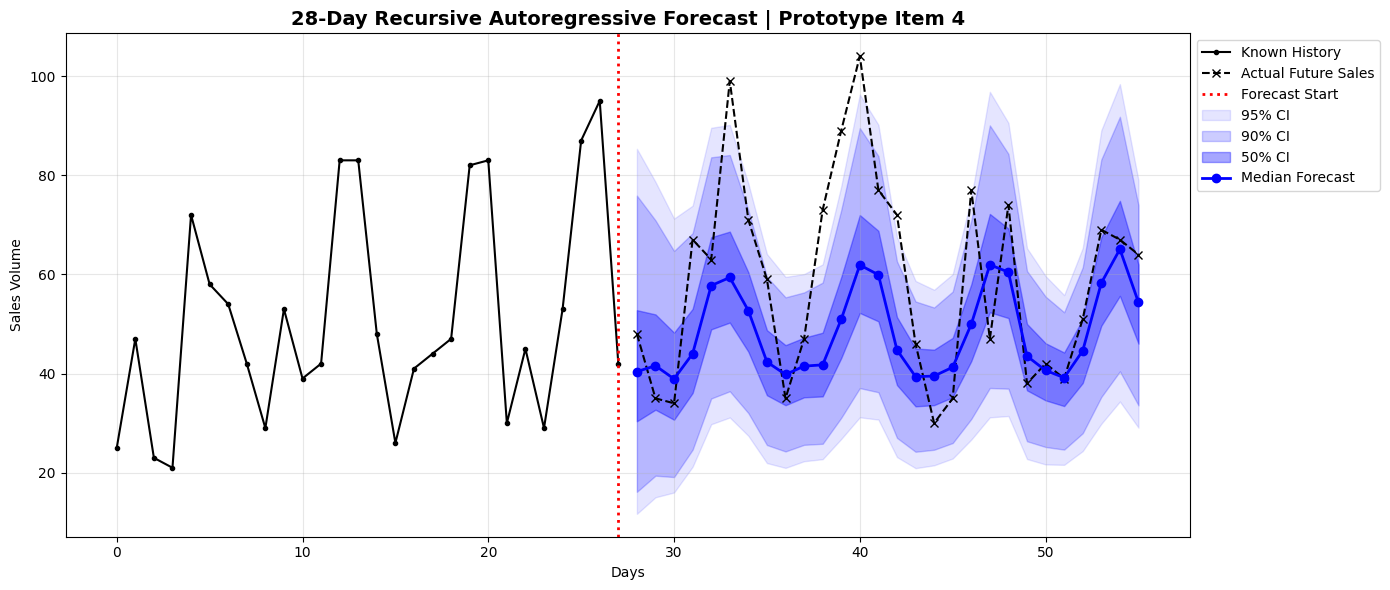


✅ Pipeline Complete!


In [10]:


# ==========================================
# 2. MAIN TRAINING PIPELINE
# ==========================================
def main():
    print("="*50)
    print("🚀 STARTING M5 QUANTILE FORECASTING PIPELINE")
    print("="*50)

    # Ensure CUDA optimizations are on if using GPU
    if DEVICE.type == 'cuda':
        torch.backends.cudnn.benchmark = True
        print("⚡ CUDA Optimizations Enabled!")

    # --- 1. Data Pipeline ---
    print("\n[1/4] Running Data Pipeline...")
    raw_data = download_m5_data()
    prototype_data = trim_data(raw_data, NUM_ITEMS_TO_KEEP)
    processed_tensors = preprocess_data(prototype_data)

    # Move tensors to the appropriate device
    X_train = processed_tensors["X_train"].to(DEVICE)
    y_train = processed_tensors["y_train"].to(DEVICE)
    X_test = processed_tensors["X_test"].to(DEVICE)
    y_test = processed_tensors["y_test"].to(DEVICE)

    print(f"📊 Data Loaded into Memory ({DEVICE}):")
    print(f"   Train X: {X_train.shape} | Train y: {y_train.shape}")
    print(f"   Test X:  {X_test.shape}  | Test y:  {y_test.shape}")

    # Create PyTorch DataLoaders for batching
    train_dataset = TensorDataset(X_train, y_train)

    # Added pin_memory and num_workers to speed up CUDA transfers
    # Turn off workers and pin_memory since the data is already on the GPU
    kwargs = {'num_workers': 0, 'pin_memory': False} if DEVICE.type == 'cuda' else {}
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **kwargs)

    # --- 2. Model, Loss, and Optimizer Setup ---
    print("\n[2/4] Initializing Model and Optimizer...")
    INPUT_DIM = X_train.shape[2] # Should be 1 for univariate
    HIDDEN_DIM = 64
    NUM_QUANTILES = len(QUANTILES)

    model = QuantileLSTM(INPUT_DIM, HIDDEN_DIM, NUM_QUANTILES).to(DEVICE)

    criterion = PinballLoss(QUANTILES)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # --- 3. Training Loop ---
    EPOCHS = 10 # Set to 5 per your request
    print(f"\n[3/4] ⚙️ Starting Training Loop for {EPOCHS} Epochs...")

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        start_time = time.time()

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad(set_to_none=True) # Slightly faster than standard zero_grad()
            preds = model(batch_X)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        elapsed = time.time() - start_time
        print(f"   Epoch {epoch+1}/{EPOCHS} | Avg Loss: {avg_loss:.4f} | Time: {elapsed:.2f}s")

    # --- 4. Evaluation & Visualization ---
    print("\n[4/4] 📈 Evaluating via 28-Day Recursive Forecast...")
    model.eval()

    X_test_np = X_test.cpu().numpy()
    y_test_np = y_test.cpu().numpy()

    print("\n🔮 Generating Forecasts for Top 5 Items...")

    # Loop over the first 5 items instead of just item 0
    items_to_plot = min(5, X_test_np.shape[0])

    for item_idx in range(items_to_plot):
        print(f"   -> Processing Item {item_idx}...")

        # Grab the seed window (last 28 days of known data)
        seed_window = X_test_np[item_idx, :, 0]
        actual_future = y_test_np[item_idx]

        # Generate the recursive forecast
        recursive_preds = predict_28_days_recursive(
            model=model,
            initial_history=seed_window,
            quantiles_list=QUANTILES,
            device=DEVICE
        )

        # Calculate metrics for this specific item
        print(f"      Metrics for Item {item_idx}:")
        calculate_validation_metrics(
            np.expand_dims(recursive_preds, axis=0),
            np.expand_dims(actual_future, axis=0),
            QUANTILES
        )

        # Visualize
        plot_28_day_forecast(
            historical=seed_window,
            future_actuals=actual_future,
            future_preds=recursive_preds,
            quantiles_list=QUANTILES,
            title=f"28-Day Recursive Autoregressive Forecast | Prototype Item {item_idx}"
        )

    print("\n✅ Pipeline Complete!")

if __name__ == "__main__":
    main()

## Addressing Forecast "Damping" & Extreme Events
While the current **QuantileLSTM** captures the general trend, it can be "conservative" during extreme sales spikes. It tends to regress toward the median rather than committing to high-volume outliers.

### Why the Current Model Struggles with Extremes
* **Context Blindness:** The univariate model only sees past sales. It doesn't yet know if a spike is caused by a price drop or a SNAP grocery assistance day.
* **Recursive Error Accumulation:** In a recursive loop, a small underestimation on Day 1 is fed back into the model, which can lead to "dampened" peaks by Day 28.

### The Roadmap: BHM & TFT
To capture these extremes for the final version, we are moving toward:
* **Bayesian Hierarchical Models (BHM):** Allows information sharing across the M5 hierarchy (Items → Stores → States), helping the model learn that spikes in one category often happen across a whole region.
* **Temporal Fusion Transformers (TFT):** Uses attention mechanisms and "Known Futures" (like upcoming holidays) to predict spikes before they even appear in the sales history.

## 6. Evaluation & Visualization (Seeing is Believing)
* **Metrics:** Calculates MAE and RMSE comparing the median forecast against actual unseen test data.
* **The Graph:** Generates clear charts for sample items, plotting the known past and the actual future. Shaded zones for 50%, 90%, and 95% confidence intervals prove how the model manages inventory risk.